In [1]:
# ==============================================================================
# IMPORTING ALL NECESSARY LIBRARIES FOR DATA SCIENCE PIPELINE
# ==============================================================================

# Librairies de base pour la manipulation des donnees
import pandas as pd
import numpy as np

# Librairies de visualisation pour l'analyse exploratoire (EDA)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot, iplot, init_notebook_mode

# Initialisation du mode notebook pour les graphiques interactifs Plotly
init_notebook_mode(connected=True)

# Commande magique pour afficher les graphiques Matplotlib directement sous la cellule
%matplotlib inline

# Outils de pretraitement des donnees (Preprocessing)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Algorithmes de Machine Learning pour la classification
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

# Outils pour la creation de pipelines et la recherche d'hyperparametres
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV

# Metriques d'evaluation de la performance des modeles
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

# Gestion des alertes pour garder la console propre
import warnings
warnings.filterwarnings("ignore")

print("Tous les packages ont ete importes avec succes !")

Tous les packages ont ete importes avec succes !


In [2]:
# ==============================================================================
# Chargement du dataset PaySim et verification de la presence de valeurs manquantes
# ==============================================================================

# Configuration de pandas pour afficher toutes les colonnes sans coupure
pd.set_option('display.max_columns', None)

# Definition du chemin d'acces au fichier csv de Kaggle PaySim
dataset_path = "datasets/PS_20174392719_1491204439457_log.csv"

# Chargement du dataset complet avec Pandas
print("Chargement des donnees en cours...")
df_paysim = pd.read_csv(dataset_path)
print("Chargement termine avec succes !\n")

# Affichage des dimensions reelles du dataset
print("--- Dimensions du Dataset ---")
print(f"Nombre de lignes : {df_paysim.shape[0]:,}")
print(f"Nombre de colonnes : {df_paysim.shape[1]}\n")

# Verification des types de donnees et de la memoire utilisee
print("--- Informations generales sur les colonnes ---")
print(df_paysim.info())

# Verification stricte de la presence de valeurs manquantes (NaN)
print("\n--- Verification des valeurs manquantes ---")
missing_counts = df_paysim.isnull().sum()
if missing_counts.sum() == 0:
    print("Parfait ! Aucune valeur manquante n'a ete detectee dans ce dataset.")
else:
    print("Attention, colonnes avec valeurs manquantes :")
    print(missing_counts[missing_counts > 0])

# Apercu des 5 premieres lignes du dataset
print("\n--- Apercu des 5 premieres lignes ---")
df_paysim.head()

Chargement des donnees en cours...
Chargement termine avec succes !

--- Dimensions du Dataset ---
Nombre de lignes : 6,362,620
Nombre de colonnes : 11

--- Informations generales sur les colonnes ---
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None

--- Verification des valeurs manquantes ---
Parfait ! Aucune valeur manquante n'a ete detectee dans ce dataset.

--- Apercu des 5 premieres lignes ---


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


--- Debut de l Analyse Multivariee et des Correlations ---


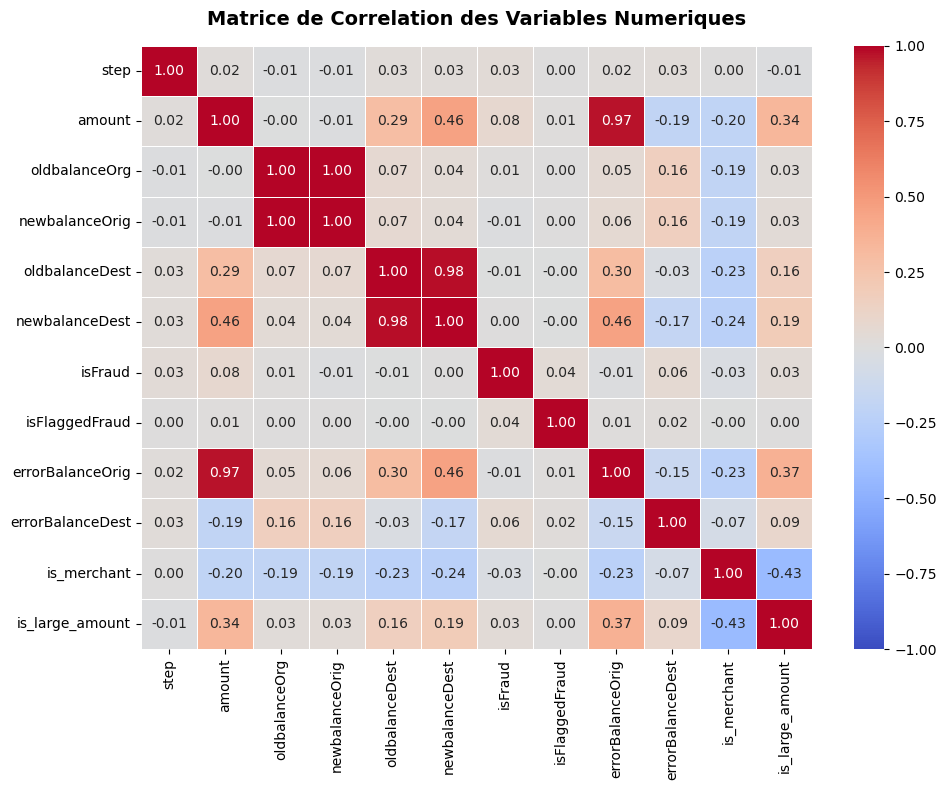


--- Analyse multivariee : Distribution des montants pour les fraudes ---


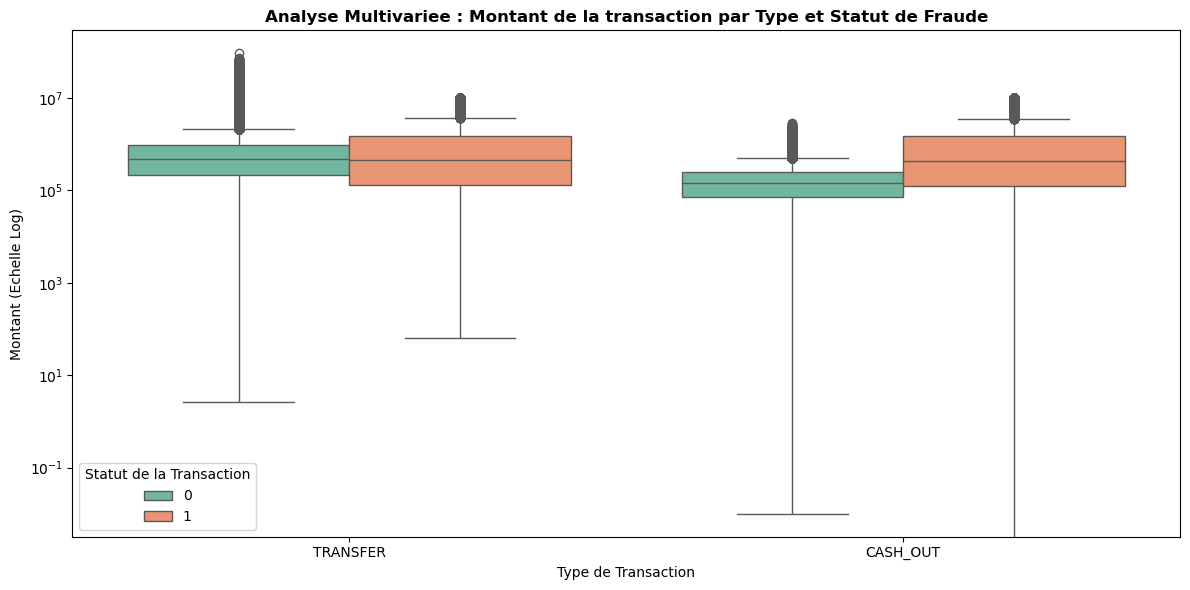

In [16]:
print("--- Debut de l Analyse Multivariee et des Correlations ---")

numerical_cols = df_paysim.select_dtypes(include=[np.number]).columns
corr_matrix = df_paysim[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matrice de Correlation des Variables Numeriques", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n--- Analyse multivariee : Distribution des montants pour les fraudes ---")
plt.figure(figsize=(12, 6))
df_filtered = df_paysim[df_paysim['type'].isin(['TRANSFER', 'CASH_OUT'])]

sns.boxplot(
    x='type',
    y='amount',
    hue='isFraud',
    data=df_filtered,
    palette='Set2'
)
plt.yscale('log')
plt.title("Analyse Multivariee : Montant de la transaction par Type et Statut de Fraude", fontsize=12, fontweight='bold')
plt.xlabel("Type de Transaction")
plt.ylabel("Montant (Echelle Log)")
plt.legend(title="Statut de la Transaction")
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# CELL 3: FEATURE ENGINEERING (Creation de nouvelles variables et transformation des variables existantes)
# ==============================================================================

# Calcul des ecarts de solde pour le compte emetteur (Origine)
# Nous calculons l'erreur s'il y a un ecart (ex: frais caches, fraude)
df_paysim['errorBalanceOrig'] = df_paysim['newbalanceOrig'] + df_paysim['amount'] - df_paysim['oldbalanceOrg']

# Calcul des ecarts de solde pour le compte recepteur
df_paysim['errorBalanceDest'] = df_paysim['oldbalanceDest'] + df_paysim['amount'] - df_paysim['newbalanceDest']

# Creation d'un indicateur pour les marchands (Merchants)
# Extraction binaire : 1 si c'est un marchand, 0 sinon
df_paysim['is_merchant'] = df_paysim['nameDest'].str.startswith('M').astype(int)

# 4. Indicateur de grands montants (Surge Indicator)
# Nous marquons les transactions dont le montant est superieur au 75eme percentile complet (~200,000)
# Cela aide le modele a cibler les transferts massifs inhabituels
df_paysim['is_large_amount'] = (df_paysim['amount'] > 200000).astype(int)

# Affichage des nouvelles colonnes creees pour verification
print("--- Nouvelles variables creees avec succes ---")
print(df_paysim[['errorBalanceOrig', 'errorBalanceDest', 'is_merchant', 'is_large_amount']].head())

print("\nNombre total de colonnes actuel :", df_paysim.shape[1])

--- Nouvelles variables creees avec succes ---
   errorBalanceOrig  errorBalanceDest  is_merchant  is_large_amount
0               0.0           9839.64            1                0
1               0.0           1864.28            1                0
2               0.0            181.00            0                0
3               0.0          21363.00            0                0
4               0.0          11668.14            1                0

Nombre total de colonnes actuel : 15
--- Nouvelles variables creees avec succes ---
   errorBalanceOrig  errorBalanceDest  is_merchant  is_large_amount
0               0.0           9839.64            1                0
1               0.0           1864.28            1                0
2               0.0            181.00            0                0
3               0.0          21363.00            0                0
4               0.0          11668.14            1                0

Nombre total de colonnes actuel : 15


In [8]:
# ==============================================================================
# DATA SPLITTING (TRAIN / TEST SPLIT FOR SECURITY)
# ==============================================================================

# 1. Definition de la variable cible (y) et des variables explicatives (X)
# 'isFraud' est l'etiquette que notre modele doit apprendre a predire
X = df_paysim.drop(columns=['isFraud'])
y = df_paysim['isFraud']

# 2. Division du dataset : 70% pour l'entrainement et 30% pour le test
# Nous fixons le random_state a 42 pour que le decoupage soit reproductible
# L'option stratify=y est tres importante : elle garantit la meme proportion
# de fraudes dans le Train et dans le Test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 3. Affichage des dimensions pour verifier le decoupage
print("--- Resultat du decoupage des donnees ---")
print(f"X_train (Entrainement) : {X_train.shape[0]:,} lignes, {X_train.shape[1]} colonnes")
print(f"X_test (Validation)   : {X_test.shape[0]:,} lignes, {X_test.shape[1]} colonnes")

# 4. Verification de la stratification du taux de fraude
print("\n--- Distribution de la cible (Taux de fraude) ---")
print(f"Proportion de fraude dans Train : {(y_train.sum() / len(y_train)) * 100:.4f}%")
print(f"Proportion de fraude dans Test  : {(y_test.sum() / len(y_test)) * 100:.4f}%")

--- Resultat du decoupage des donnees ---
X_train (Entrainement) : 4,453,834 lignes, 14 colonnes
X_test (Validation)   : 1,908,786 lignes, 14 colonnes

--- Distribution de la cible (Taux de fraude) ---
Proportion de fraude dans Train : 0.1291%
Proportion de fraude dans Test  : 0.1291%
--- Resultat du decoupage des donnees ---
X_train (Entrainement) : 4,453,834 lignes, 14 colonnes
X_test (Validation)   : 1,908,786 lignes, 14 colonnes

--- Distribution de la cible (Taux de fraude) ---
Proportion de fraude dans Train : 0.1291%
Proportion de fraude dans Test  : 0.1291%


In [10]:
# ==============================================================================
# DEFINING THE PREPROCESSING PIPELINE WITH COLUMNTRANSFORMER
# ==============================================================================

# 1. Definition des groupes de colonnes selon le traitement requis
# Variables numeriques qui ont besoin d'etre normalisees (StandardScaler)
numeric_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'errorBalanceOrig',
    'errorBalanceDest'
]

# Variables categoriques qui doivent etre encodees (OneHotEncoder)
categorical_features = ['type']

# Variables binaires ou deja numeriques qu'on laisse telles quelles (Pas de traitement requis)
passthrough_features = ['step', 'is_merchant', 'is_large_amount']

# 2. Construction du ColumnTransformer
# Nous n'avons pas besoin de SimpleImputer ici car nous avons verifie qu'il n'y a pas de NaN
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        # Applique un StandardScaler sur les montants et soldes
        ('num_scaling', Pipeline([
            ('scaler', StandardScaler())
        ]), numeric_features),

        # Applique le OneHotEncoder sur la colonne 'type'
        # handle_unknown='ignore' evite les crashs si une categorie bizarre apparait plus tard
        ('cat_encoding', Pipeline([
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features),

        # Bloc Passthrough : Garde les colonnes deja prêtes sans les modifier
        ('pass_features', 'passthrough', passthrough_features)
    ],
    # Les colonnes non mentionnees (comme nameOrig, nameDest, isFlaggedFraud) seront supprimees
    remainder='drop'
)

print("Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !")
print("Il est pret a recevoir les donnees d'entrainement et de test.")

Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !
Il est pret a recevoir les donnees d'entrainement et de test.
Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !
Il est pret a recevoir les donnees d'entrainement et de test.


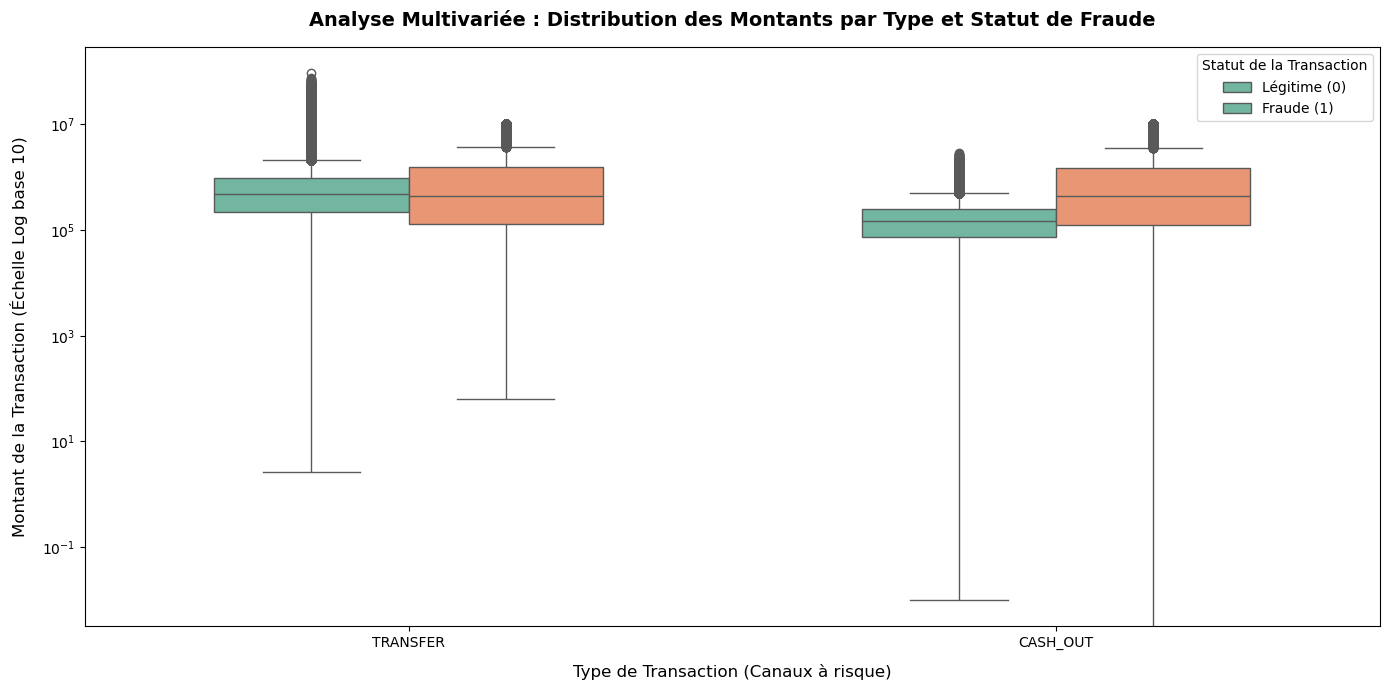

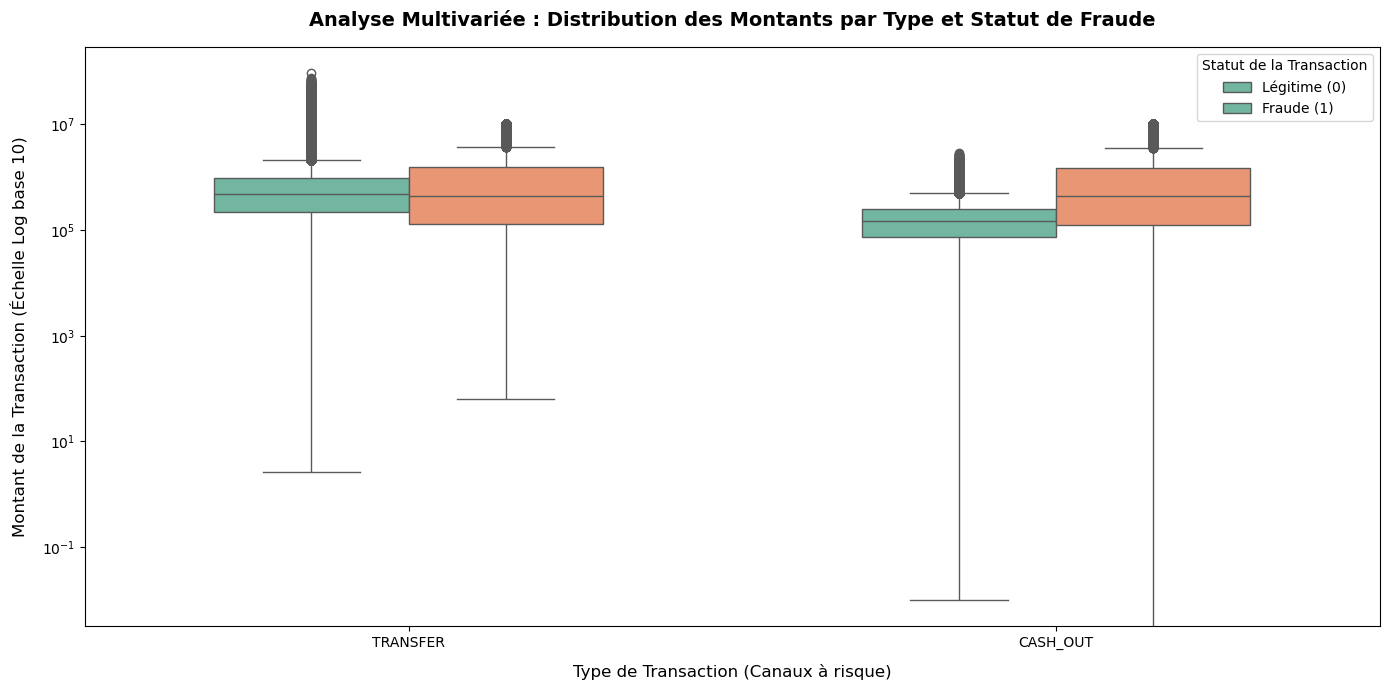

In [12]:
# ==============================================================================
# GÉNÉRATION DU BOXPLOT MULTIVARIÉ (MONTANT PAR TYPE ET FRAUDE)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition de la taille du graphique
plt.figure(figsize=(14, 7))

# 2. Filtrage des données pour ne garder que les types où la fraude existe
# Cela évite d'avoir des boîtes vides pour CASH_IN, DEBIT et PAYMENT
df_filtered = df_paysim[df_paysim['type'].isin(['TRANSFER', 'CASH_OUT'])]

# 3. Création du Boxplot multivarié
sns.boxplot(
    data=df_filtered,
    x='type',             # Axe X : Le type de transaction
    y='amount',           # Axe Y : Le montant
    hue='isFraud',        # Couleur : Séparation Légitime (0) / Fraude (1)
    palette='Set2',       # Palette de couleurs pro et lisible
    width=0.6             # Largeur des boîtes pour un rendu épuré
)

# 4. Passage à l'échelle logarithmique (CRUCIAL)
# Les montants vont de 0.1 à 100 000 000. Sans échelle log, les boîtes seraient écrasées en bas.
plt.yscale('log')

# 5. Habillage et titres professionnels pour le rapport
plt.title(
    "Analyse Multivariée : Distribution des Montants par Type et Statut de Fraude",
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel("Type de Transaction (Canaux à risque)", fontsize=12, labelpad=10)
plt.ylabel("Montant de la Transaction (Échelle Log base 10)", fontsize=12, labelpad=10)

# Personnalisation de la légende
plt.legend(title="Statut de la Transaction", labels=["Légitime (0)", "Fraude (1)"])

# Ajustement des marges
plt.tight_layout()

# 6. Affichage du graphique
plt.show()

In [14]:
# ==============================================================================
# EXECUTION DU PIPELINE DE PREPROCESSING SUR LES DONNEES D'ENTRAINEMENT ET DE TEST
# ==============================================================================

# 1. Entrainement et transformation des donnees d'entrainement (Train Set)
# Le pipeline apprend les moyennes/ecarts-types (StandardScaler) et les categories (OHE)
# uniquement sur le Train Set pour eviter toute fuite de donnees (Data Leakage)
print("Execution du pretraitement sur le Train Set...")
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# 2. Transformation des donnees de test (Test Set)
# On utilise uniquement .transform() ici, on ne fait SURTOUT PAS de .fit()
# Le Test Set doit etre traite exactement avec les regles apprises sur le Train Set
print("Execution du pretraitement sur le Test Set...")
X_test_processed = preprocessing_pipeline.transform(X_test)

# 3. Recouvrement des noms de colonnes apres transformation
# Le ColumnTransformer retourne un tableau NumPy brut. Pour garder un code propre
# et verifier les colonnes, nous reconstruisons un DataFrame Pandas.
new_columns_names = preprocessing_pipeline.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_processed, columns=new_columns_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=new_columns_names, index=X_test.index)

# 4. Affichage des resultats et des dimensions
print("\n--- Dimensions apres passage dans le Pipeline ---")
print(f"X_train_final : {X_train_final.shape[0]:,} lignes, {X_train_final.shape[1]} colonnes")
print(f"X_test_final  : {X_test_final.shape[0]:,} lignes, {X_test_final.shape[1]} colonnes\n")

print("--- Liste de toutes les colonnes pretes pour le Machine Learning ---")
print(list(X_train_final.columns))

# Apercu des premieres lignes traitees
X_train_final.head()

Execution du pretraitement sur le Train Set...
Execution du pretraitement sur le Test Set...

--- Dimensions apres passage dans le Pipeline ---
X_train_final : 4,453,834 lignes, 15 colonnes
X_test_final  : 1,908,786 lignes, 15 colonnes

--- Liste de toutes les colonnes pretes pour le Machine Learning ---
['num_scaling__amount', 'num_scaling__oldbalanceOrg', 'num_scaling__newbalanceOrig', 'num_scaling__oldbalanceDest', 'num_scaling__newbalanceDest', 'num_scaling__errorBalanceOrig', 'num_scaling__errorBalanceDest', 'cat_encoding__type_CASH_IN', 'cat_encoding__type_CASH_OUT', 'cat_encoding__type_DEBIT', 'cat_encoding__type_PAYMENT', 'cat_encoding__type_TRANSFER', 'pass_features__step', 'pass_features__is_merchant', 'pass_features__is_large_amount']


,num_scaling__amount,num_scaling__oldbalanceOrg,num_scaling__newbalanceOrig,num_scaling__oldbalanceDest,num_scaling__newbalanceDest,num_scaling__errorBalanceOrig,num_scaling__errorBalanceDest,cat_encoding__type_CASH_IN,cat_encoding__type_CASH_OUT,cat_encoding__type_DEBIT,cat_encoding__type_PAYMENT,cat_encoding__type_TRANSFER,pass_features__step,pass_features__is_merchant,pass_features__is_large_amount
4310249,0.133805,-0.277631,-0.192460,1.042527,0.859216,0.528919,1.050432,1.0,0.0,0.0,0.0,0.0,308.0,0.0,1.0
318938,2.005310,-0.139123,-0.292551,-0.324812,-0.052308,1.245720,0.672722,0.0,0.0,0.0,0.0,1.0,16.0,0.0,1.0
3375139,1.595985,-0.268089,-0.292551,-0.320385,-0.018948,1.454648,-0.125395,0.0,0.0,0.0,0.0,1.0,254.0,0.0,1.0
5492781,-0.017525,-0.261134,-0.207299,0.108104,0.019806,0.227606,0.639231,1.0,0.0,0.0,0.0,0.0,380.0,0.0,0.0
807263,-0.290836,1.783478,1.756078,0.150109,0.103563,-0.316584,-0.103424,1.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0


Execution du pretraitement sur le Train Set...
Execution du pretraitement sur le Test Set...

--- Dimensions apres passage dans le Pipeline ---
X_train_final : 4,453,834 lignes, 15 colonnes
X_test_final  : 1,908,786 lignes, 15 colonnes

--- Liste de toutes les colonnes pretes pour le Machine Learning ---
['num_scaling__amount', 'num_scaling__oldbalanceOrg', 'num_scaling__newbalanceOrig', 'num_scaling__oldbalanceDest', 'num_scaling__newbalanceDest', 'num_scaling__errorBalanceOrig', 'num_scaling__errorBalanceDest', 'cat_encoding__type_CASH_IN', 'cat_encoding__type_CASH_OUT', 'cat_encoding__type_DEBIT', 'cat_encoding__type_PAYMENT', 'cat_encoding__type_TRANSFER', 'pass_features__step', 'pass_features__is_merchant', 'pass_features__is_large_amount']


,num_scaling__amount,num_scaling__oldbalanceOrg,num_scaling__newbalanceOrig,num_scaling__oldbalanceDest,num_scaling__newbalanceDest,num_scaling__errorBalanceOrig,num_scaling__errorBalanceDest,cat_encoding__type_CASH_IN,cat_encoding__type_CASH_OUT,cat_encoding__type_DEBIT,cat_encoding__type_PAYMENT,cat_encoding__type_TRANSFER,pass_features__step,pass_features__is_merchant,pass_features__is_large_amount
4310249,0.133805,-0.277631,-0.192460,1.042527,0.859216,0.528919,1.050432,1.0,0.0,0.0,0.0,0.0,308.0,0.0,1.0
318938,2.005310,-0.139123,-0.292551,-0.324812,-0.052308,1.245720,0.672722,0.0,0.0,0.0,0.0,1.0,16.0,0.0,1.0
3375139,1.595985,-0.268089,-0.292551,-0.320385,-0.018948,1.454648,-0.125395,0.0,0.0,0.0,0.0,1.0,254.0,0.0,1.0
5492781,-0.017525,-0.261134,-0.207299,0.108104,0.019806,0.227606,0.639231,1.0,0.0,0.0,0.0,0.0,380.0,0.0,0.0
807263,-0.290836,1.783478,1.756078,0.150109,0.103563,-0.316584,-0.103424,1.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0


In [15]:
# ==============================================================================
# ETRAINEMENT DU MODELE DE MACHINE LEARNING (RANDOM FOREST CLASSIFIER) SUR TOUT LE TRAIN SET
# ==============================================================================

# 1. Definition des modeles rapides pour la validation croisee
fast_models_dict = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}

print("--- 1. Debut de l'evaluation des modeles rapides (3-Fold CV) ---")

# Dictionnaire pour stocker les scores
cv_results = {}

# Boucle pour evaluer les modeles rapides de maniere robuste
for model_name, model_object in fast_models_dict.items():
    print(f"Evaluation en cours pour : {model_name}...")

    # Nous passons a cv=3 pour reduire encore le temps sur les 4.4 millions de lignes
    cv_scores = cross_val_score(
        model_object,
        X_train_final,
        y_train,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )

    cv_results[model_name] = cv_scores.mean()
    print(f"--> {model_name} - Score moyen de precision (Accuracy) : {cv_scores.mean():.6f}\n")


print("--- 2. Entrainement direct du Random Forest (Sans Cross-Validation) ---")
print("Entrainement en cours...")

# Declaration du Random Forest avec 50 arbres et utilisation de tous les coeurs (n_jobs=-1)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Entrainement direct unique sur la totalite du Train Set final
rf_model.fit(X_train_final, y_train)

# Calcul du score direct sur le Train Set pour comparaison
rf_train_score = rf_model.score(X_train_final, y_train)
print(f"--> Random Forest - Precision directe sur Train Set : {rf_train_score:.6f}\n")

print("--- Toutes les evaluations et entrainements sont termines ! ---")

--- 1. Debut de l'evaluation des modeles rapides (3-Fold CV) ---
Evaluation en cours pour : Logistic Regression...
--> Logistic Regression - Score moyen de precision (Accuracy) : 0.999274

Evaluation en cours pour : Decision Tree...
--> Decision Tree - Score moyen de precision (Accuracy) : 0.999986

Evaluation en cours pour : Gaussian Naive Bayes...
--> Gaussian Naive Bayes - Score moyen de precision (Accuracy) : 0.576623

--- 2. Entrainement direct du Random Forest (Sans Cross-Validation) ---
Entrainement en cours...
--> Random Forest - Precision directe sur Train Set : 1.000000

--- Toutes les evaluations et entrainements sont termines ! ---


In [ ]:
# ==============================================================================
# EVALUATION FINALE DU MODELE RANDOM FOREST ET DECISION TREE SUR LE TEST SET
# ==============================================================================

# Nous devons juste recuperer une Decision Tree entraine proprement pour le test.
dt_model = fast_models_dict['Decision Tree'].fit(X_train_final, y_train)

# 1. Predictions sur le Test Set
print("Calcul des predictions sur le Test Set pour les deux modeles...")
y_pred_dt = dt_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)

# 2. Evaluation du Decision Tree
print("\n==================================================")
print("   EVALUATION DU MODELE : DECISION TREE")
print("====================================================")
print("\n--- Classification Report (Decision Tree) ---")
print(classification_report(y_test, y_pred_dt, target_names=['Legitime', 'Fraude']))

print("--- Matrice de Confusion (Decision Tree) ---")
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_dt:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_dt:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_dt:,}")

# 3. Evaluation du Random Forest
print("\n==================================================")
print("   EVALUATION DU MODELE : RANDOM FOREST")
print("==================================================")
print("\n--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Legitime', 'Fraude']))

print("--- Matrice de Confusion (Random Forest) ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_rf:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_rf:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_rf:,}")

In [ ]:
# ==============================================================================
# VISUALIZING FEATURE IMPORTANCE WITH BALANCE ERRORS
# ==============================================================================

# 1. Extraction de l'importance des variables calculees par le Random Forest du premier modele
importances_with_error = rf_model.feature_importances_
feature_names_with_error = X_train_final.columns

# Creation du DataFrame ordonne
df_importance_with_error = pd.DataFrame({
    'Feature': feature_names_with_error,
    'Importance': importances_with_error
}).sort_values(by='Importance', ascending=False)

# 2. Creation du graphique avec Seaborn et Matplotlib
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance_with_error,
    palette='magma'
)

# Ajout des titres et labels
plt.title("Importance des Variables - Random Forest (AVEC errorBalance)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Score d'Importance Relative", fontsize=12)
plt.ylabel("Variables (Features)", fontsize=12)
plt.tight_layout()

# Affichage du graphique dans le premier notebook
plt.show()

# 3. Affichage textuel du Top 5 pour ton rapport
print("--- Top 5 des variables les plus discriminantes (Notebook 1) ---")
print(df_importance_with_error.head(5).to_string(index=False))

## Analyse en Composantes Principales (ACP) et complément non supervisé

Cette section répond aux exigences de la note de cadrage (section 4.5 - Fondements mathématiques mobilisés : variance expliquée, distance, normalisation) et à la méthodologie annoncée dans le résumé du projet intégrateur (ACP, Isolation Forest).

In [ ]:
# ==============================================================================
# ANALYSE EN COMPOSANTES PRINCIPALES (ACP / PCA)
# ==============================================================================
from sklearn.decomposition import PCA

print("--- Debut de l'Analyse en Composantes Principales (ACP) ---")

# 1. Application de l'ACP sur les donnees pretraitees (deja standardisees par le pipeline)
# On garde toutes les composantes pour analyser la variance expliquee
pca_full = PCA(random_state=42)
pca_full.fit(X_train_final)

# 2. Variance expliquee par chaque composante
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# 3. Graphique Eboulis des valeurs propres (Scree plot) + variance cumulee
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, color='steelblue', label='Variance expliquee (individuelle)')
ax1.set_xlabel("Composante Principale")
ax1.set_ylabel("Proportion de variance expliquee", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(explained_var)+1), cumulative_var, color='darkred', marker='o', label='Variance cumulee')
ax2.axhline(y=0.90, color='green', linestyle='--', label='Seuil 90%')
ax2.set_ylabel("Variance cumulee", color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

fig.legend(loc='center right', bbox_to_anchor=(0.9, 0.5))
plt.title("Eboulis des valeurs propres - ACP (Scree Plot)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# 4. Nombre de composantes necessaires pour 90% de variance
n_components_90 = int(np.argmax(cumulative_var >= 0.90) + 1)
print(f"--> Nombre de composantes necessaires pour expliquer 90% de la variance : {n_components_90}")
print(f"--> Variance expliquee par les 2 premieres composantes : {cumulative_var[1]*100:.2f}%")


In [ ]:
# ==============================================================================
# PROJECTION 2D DE L'ACP (PC1 vs PC2) COLOREE PAR STATUT DE FRAUDE
# ==============================================================================

# 1. Reduction a 2 composantes pour la visualisation
pca_2d = PCA(n_components=2, random_state=42)

# Echantillonnage stratifie pour la lisibilite du graphique
# (4.4M points rendrait un scatter illisible) : on garde TOUTES les fraudes
# + un echantillon aleatoire de transactions legitimes
sample_size_legit = 20000
idx_fraud = y_train[y_train == 1].index
idx_legit = y_train[y_train == 0].sample(n=sample_size_legit, random_state=42).index
idx_sample = idx_fraud.union(idx_legit)

X_sample = X_train_final.loc[idx_sample]
y_sample = y_train.loc[idx_sample]

X_pca_2d = pca_2d.fit_transform(X_sample)

# 2. Scatter plot des 2 premieres composantes
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_2d[y_sample.values==0, 0], X_pca_2d[y_sample.values==0, 1],
            s=8, alpha=0.3, c='steelblue', label='Legitime')
plt.scatter(X_pca_2d[y_sample.values==1, 0], X_pca_2d[y_sample.values==1, 1],
            s=15, alpha=0.7, c='crimson', label='Fraude')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Projection ACP (PC1 vs PC2) : Legitime vs Fraude", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# CERCLE DES CORRELATIONS : CONTRIBUTION DES VARIABLES AUX AXES PC1/PC2
# ==============================================================================

loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))
circle = plt.Circle((0, 0), 1, color='grey', fill=False, linestyle='--')
ax.add_artist(circle)

for i, feature in enumerate(X_train_final.columns):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.02, color='darkorange', alpha=0.8)
    ax.text(loadings[i, 0]*1.12, loadings[i, 1]*1.12, feature, fontsize=8, ha='center')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cercle des Correlations - Contribution des Variables", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tableau des contributions triees par poids sur PC1
df_loadings = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=X_train_final.columns)
print("--- Contribution des variables aux 2 premiers axes (triee par |PC1|) ---")
print(df_loadings.reindex(df_loadings['PC1'].abs().sort_values(ascending=False).index))


## Détection d'anomalies non supervisée (Isolation Forest)

Le résumé du projet intégrateur annonce une comparaison entre une approche supervisée (labels disponibles ici, contrairement à un contexte de production réel) et une approche non supervisée. Cette section fournit ce complément, cohérent avec les mots-clés officiels du sujet (Isolation Forest, DBSCAN, ACP).

In [ ]:
# ==============================================================================
# DETECTION D'ANOMALIES NON SUPERVISEE : ISOLATION FOREST (complement a l'ACP)
# ==============================================================================
from sklearn.ensemble import IsolationForest

print("--- Isolation Forest : approche non supervisee complementaire ---")

# Contamination = proportion approximative de fraude observee dans le Train set
# (en production reelle, ce taux ne serait pas connu a l'avance : on l'estime ici
# uniquement a des fins de calibrage pedagogique, puisque nous disposons des labels)
contamination_rate = y_train.mean()
print(f"Taux de contamination utilise : {contamination_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_final)

# Predictions : -1 = anomalie, 1 = normal -> conversion en 0/1 pour comparer a isFraud
y_pred_iso = iso_forest.predict(X_test_final)
y_pred_iso_binary = np.where(y_pred_iso == -1, 1, 0)

print("\n--- Evaluation de l'Isolation Forest (non supervise) vs les vraies fraudes ---")
print(classification_report(y_test, y_pred_iso_binary, target_names=['Legitime', 'Fraude']))

cm_iso = confusion_matrix(y_test, y_pred_iso_binary)
print("Matrice de confusion Isolation Forest:")
print(cm_iso)
tn_iso, fp_iso, fn_iso, tp_iso = cm_iso.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_iso:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_iso:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_iso:,}")

print("\n--- Comparaison rapide Supervise (Random Forest) vs Non supervise (Isolation Forest) ---")
print("Le Random Forest exploite le label isFraud et sera nettement plus precis.")
print("L'Isolation Forest n'utilise AUCUN label : il illustre ce qui serait faisable")
print("en production quand la fraude n'est pas encore etiquetee (nouveaux schemas de fraude).")
